<a href="https://colab.research.google.com/github/Adithyasajeev22/Deep-Learning/blob/main/FNN(BINARY_CLASSIFICATION)_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**FEED FORWARD NEURAL NETWORK(BINARY_CLASSIFICATION)**

# **1.EDA**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/sms_spam_dataset.csv')
df.head(5)

,sms_id,message_length,num_links,num_special_chars,has_offer,contains_free,contains_win,contains_call,time_of_day,sender_type,region,spam
0,1,122,1.0,11.0,1,0,0,0.0,morning,business,rural,0
1,2,199,1.0,0.0,0,0,1,1.0,night,unknown,urban,0
2,3,112,3.0,9.0,1,0,0,1.0,night,business,urban,1
3,4,34,1.0,8.0,1,1,1,1.0,afternoon,personal,rural,1
4,5,126,1.0,2.0,0,1,1,1.0,evening,unknown,urban,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sms_id             5100 non-null   int64  
 1   message_length     5100 non-null   int64  
 2   num_links          4846 non-null   float64
 3   num_special_chars  4844 non-null   float64
 4   has_offer          5100 non-null   int64  
 5   contains_free      5100 non-null   int64  
 6   contains_win       5100 non-null   int64  
 7   contains_call      4842 non-null   float64
 8   time_of_day        5100 non-null   object 
 9   sender_type        4846 non-null   object 
 10  region             4846 non-null   object 
 11  spam               5100 non-null   int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 478.3+ KB


In [ ]:
df.isnull().sum()

,0
sms_id,0
message_length,0
num_links,254
num_special_chars,256
has_offer,0
contains_free,0
contains_win,0
contains_call,258
time_of_day,0
sender_type,254


In [ ]:
df['region'].fillna(df['region'].mode()[0],inplace=True)
df['contains_call'].fillna(df['contains_call'].mode()[0],inplace=True)
df['sender_type'].fillna(df['sender_type'].mode()[0],inplace=True)
df['num_special_chars'].fillna(df['num_special_chars'].mode()[0],inplace=True)
df['num_links'].fillna(df['num_links'].mode()[0],inplace=True)

/tmp/ipykernel_13023/3833464680.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['region'].fillna(df['region'].mode()[0],inplace=True)
/tmp/ipykernel_13023/3833464680.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [ ]:
df.isnull().sum()

,0
sms_id,0
message_length,0
num_links,0
num_special_chars,0
has_offer,0
contains_free,0
contains_win,0
contains_call,0
time_of_day,0
sender_type,0


In [ ]:
df.duplicated().sum()

np.int64(100)

In [ ]:
df.shape

(5100, 12)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(5000, 12)

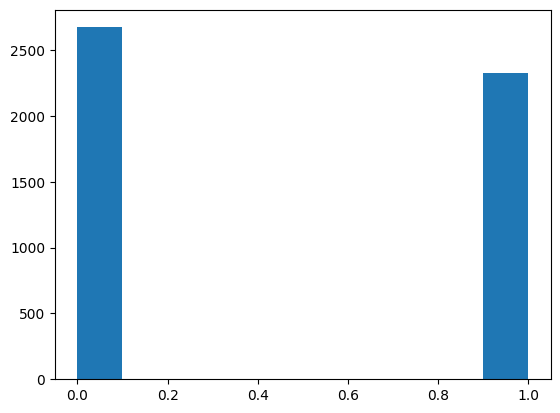

In [ ]:
plt.hist(df['spam'])
plt.show()

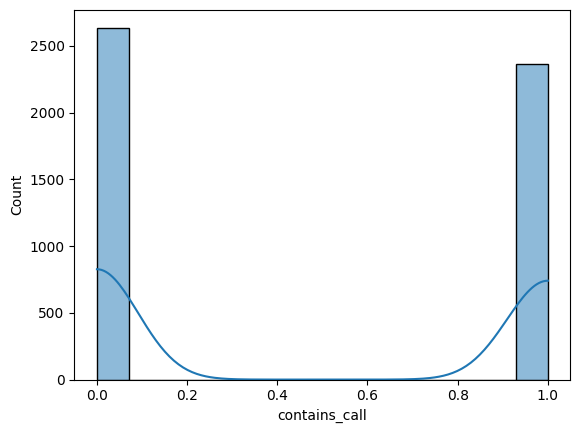

In [ ]:
sns.histplot(df['contains_call'],kde=True)
plt.show()

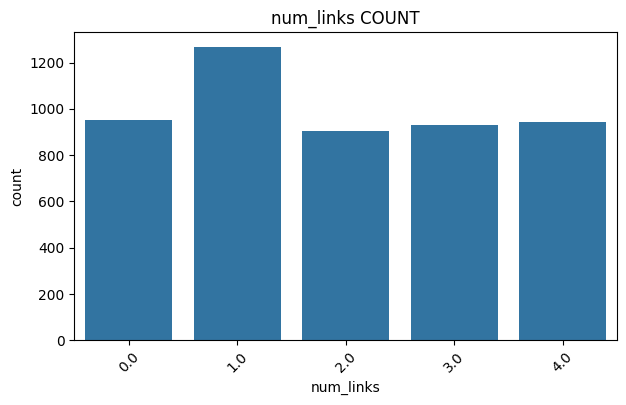

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x=df['num_links'])
plt.title("num_links COUNT")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sms_id             5000 non-null   int64  
 1   message_length     5000 non-null   int64  
 2   num_links          5000 non-null   float64
 3   num_special_chars  5000 non-null   float64
 4   has_offer          5000 non-null   int64  
 5   contains_free      5000 non-null   int64  
 6   contains_win       5000 non-null   int64  
 7   contains_call      5000 non-null   float64
 8   time_of_day        5000 non-null   object 
 9   sender_type        5000 non-null   object 
 10  region             5000 non-null   object 
 11  spam               5000 non-null   int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 507.8+ KB


In [ ]:
print(df['time_of_day'].unique())

['morning' 'night' 'afternoon' 'evening']


In [ ]:
print(df['sender_type'].unique())

['business' 'unknown' 'personal']


In [ ]:
print(df['region'].unique())

['rural' 'urban' 'semi-urban']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['sender_type']=le.fit_transform(df['sender_type'])
df['region']=le.fit_transform(df['region'])

In [ ]:
df['time_of_day'].replace(['morning','night','afternoon','evening'],[0,1,2,3],inplace=True)

/tmp/ipykernel_13023/236119402.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['time_of_day'].replace(['morning','night','afternoon','evening'],[0,1,2,3],inplace=True)
/tmp/ipykernel_13023/236119402.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['time_of_day'].replace(['morning','nigh

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sms_id             5000 non-null   int64  
 1   message_length     5000 non-null   int64  
 2   num_links          5000 non-null   float64
 3   num_special_chars  5000 non-null   float64
 4   has_offer          5000 non-null   int64  
 5   contains_free      5000 non-null   int64  
 6   contains_win       5000 non-null   int64  
 7   contains_call      5000 non-null   float64
 8   time_of_day        5000 non-null   int64  
 9   sender_type        5000 non-null   int64  
 10  region             5000 non-null   int64  
 11  spam               5000 non-null   int64  
dtypes: float64(3), int64(9)
memory usage: 507.8 KB


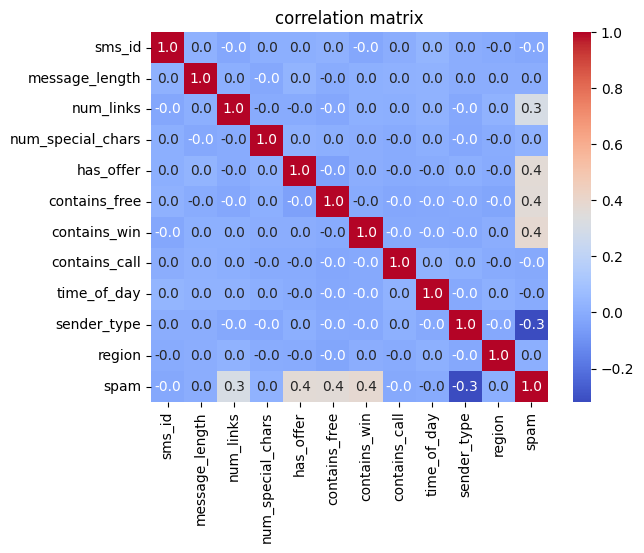

In [ ]:
corr_matrix=df.corr()

sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("correlation matrix")
plt.show()

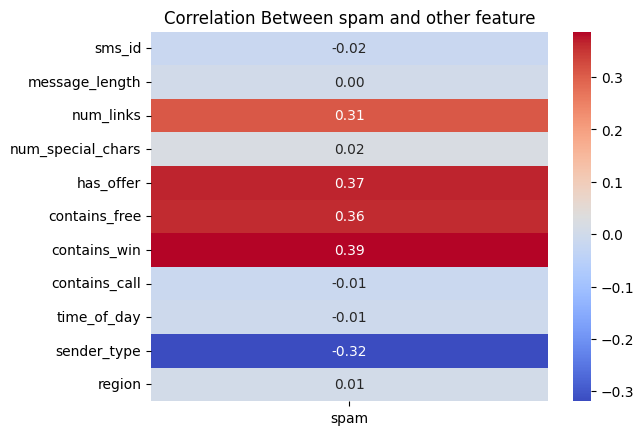

In [ ]:
status_corr=df.corr()['spam']
status_corr=status_corr.drop('spam')

sns.heatmap(status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation Between spam and other feature')
plt.show()

In [ ]:
df.drop(['message_length'],axis=1,inplace=True)

<Axes: >

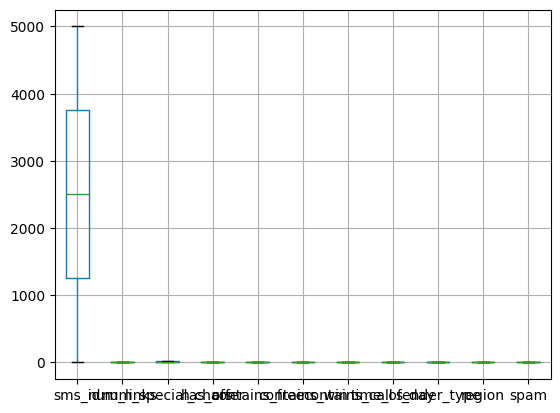

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr

    df=df[(df[col] >=lower_bound)& (df[col] <=upper_bound)]
  return df

df_cleaned=remove_outliers_iqr(df,exclude_column='spam')
df=df_cleaned

In [ ]:
df.shape

(5000, 11)

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['sms_id', 'num_links', 'num_special_chars', 'has_offer',
       'contains_free', 'contains_win', 'contains_call', 'time_of_day',
       'sender_type', 'region']

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['sms_id', 'num_links', 'num_special_chars', 'has_offer',
       'contains_free', 'contains_win', 'contains_call', 'time_of_day',
       'sender_type', 'region']]
y=df['spam']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline Model Accuracy:{accuracy:.2f}')

Baseline Model Accuracy:0.89


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# **2.FNN**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

# Defining the ANN(FNN) model
model = Sequential()
model.add(Dense(64, input_dim=10, activation='relu')) # Hidden Layer 1
model.add(Dense(32, activation='relu'))# Hidden Layer 2


model.add(Dense(1, activation='sigmoid'))# Output Layer

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training the model
model.fit(x_train, y_train, epochs=70)

# Evaluating the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Epoch 1/70


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5179 - loss: 2.5396
Epoch 2/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5248 - loss: 2.1014
Epoch 3/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5621 - loss: 1.4042
Epoch 4/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5611 - loss: 2.6433
Epoch 5/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6184 - loss: 1.1973
Epoch 6/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6152 - loss: 1.1830
Epoch 7/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6229 - loss: 1.4051
Epoch 8/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6043 - loss: 1.5643
Epoch 9/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6072 - loss: 1.6415
Epoch 10/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6925 - loss: 0.9662
Epoch 11/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6688 - loss: 1.2233
Epoch 12/70
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy